In [1]:
import os

dataset_path = "Raw_Dataset"

classes = os.listdir(dataset_path)

print("📊 Dataset Summary:\n")

for cls in classes:
    count = len(os.listdir(os.path.join(dataset_path, cls)))
    print(f"{cls}: {count} images")

📊 Dataset Summary:

Abscess: 111 images
Caries: 189 images
Impacted_tooth: 100 images


- The dataset contains three classes: Abscess, Caries, and Impacted_tooth.  
- Caries has the highest number of images (189), while Impacted_tooth has the lowest (100).  


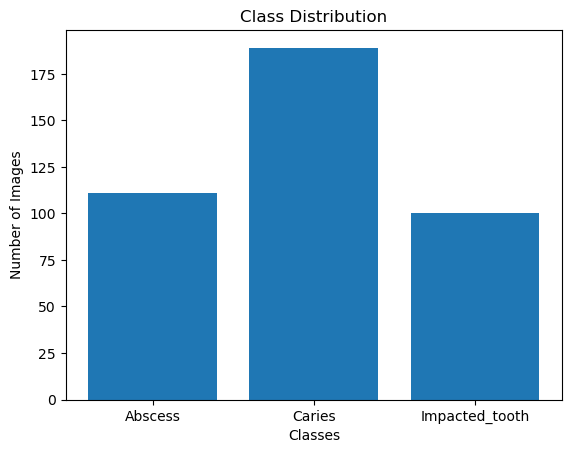

In [2]:
import matplotlib.pyplot as plt

counts = []
labels = []

for cls in classes:
    count = len(os.listdir(os.path.join(dataset_path, cls)))
    counts.append(count)
    labels.append(cls)

plt.bar(labels, counts)
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.show()

- The bar chart shows that the Caries class has the highest number of images among all categories.  
- Abscess has a moderate number of images, while Impacted_tooth has the fewest.

In [ ]:
pip install --user opencv-python

Note: you may need to restart the kernel to use updated packages.


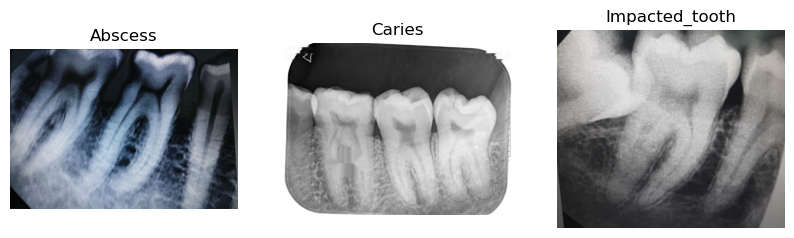

In [5]:
import cv2
import random

plt.figure(figsize=(10,5))

for i, cls in enumerate(classes):
    img_name = random.choice(os.listdir(os.path.join(dataset_path, cls)))
    img_path = os.path.join(dataset_path, cls, img_name)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, len(classes), i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.show()

- This code randomly selects one image from each class folder and displays it.  
- It helps visually inspect the dataset and understand the differences between Abscess, Caries, and Impacted_tooth images.  
- The output provides a quick overview of the sample images available in each category.

In [6]:
sizes = []

for cls in classes:
    for img_name in os.listdir(os.path.join(dataset_path, cls)):
        img_path = os.path.join(dataset_path, cls, img_name)
        img = cv2.imread(img_path)
        if img is not None:
            sizes.append(img.shape[:2])

print("Sample sizes:", sizes[:10])

Sample sizes: [(1167, 804), (886, 1171), (886, 1171), (886, 1171), (883, 1168), (883, 1168), (886, 1171), (1167, 885), (1167, 885), (886, 1171)]


- The sample images have different dimensions, indicating that the dataset does not contain uniformly sized images.   
- Since image sizes vary, resizing will be necessary before feeding them into a machine learning or deep learning model.

In [15]:
pip install --user torch torchvision torchaudio

   ---------------------------------------- 0.0/114.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/114.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/114.6 MB ? eta -:--:--
   ---------------------------------------- 0.3/114.6 MB ? eta -:--:--
   ---------------------------------------- 0.5/114.6 MB 626.7 kB/s eta 0:03:02
   ---------------------------------------- 0.5/114.6 MB 626.7 kB/s eta 0:03:02
   ---------------------------------------- 0.8/114.6 MB 659.1 kB/s eta 0:02:53
   ---------------------------------------- 0.8/114.6 MB 659.1 kB/s eta 0:02:53
   ---------------------------------------- 1.0/114.6 MB 691.1 kB/s eta 0:02:45
   ---------------------------------------- 1.3/114.6 MB 731.7 kB/s eta 0:02:35
    --------------------------------------- 1.6/114.6 MB 769.2 kB/s eta 0:02:27
    --------------------------------------- 1.6/114.6 MB 769.2 kB/s eta 0:02:27
    --------------------------------------- 1.8/114.6 MB 794.9 kB/s eta 0:02

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [1]:
import os
import cv2

input_dir = "raw_dataset"
output_dir = "processed_dataset"
classes = ["caries", "abscess", "impacted_tooth"]

IMG_SIZE = 224

for cls in classes:
    os.makedirs(os.path.join(output_dir, cls), exist_ok=True)

for cls in classes:
    for file in os.listdir(os.path.join(input_dir, cls)):
        path = os.path.join(input_dir, cls, file)

        img = cv2.imread(path)
        if img is None:
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        cv2.imwrite(os.path.join(output_dir, cls, file), img)

print("✅ Preprocessing Done")

✅ Preprocessing Done


- This code preprocesses all images in the dataset by converting them to grayscale and resizing them to 224×224 pixels.  
- The processed images are then saved into a new folder structure called `processed_dataset`.  
- Standardizing image size and color format helps prepare the dataset for model training.

In [3]:
import os, shutil, random

source = "processed_dataset"
dest = "dataset"
classes = ["caries", "abscess", "impacted_tooth"]

random.seed(42)

for split in ["train","val","test"]:
    for cls in classes:
        os.makedirs(os.path.join(dest, split, cls), exist_ok=True)

for cls in classes:
    images = os.listdir(os.path.join(source, cls))
    random.shuffle(images)

    total = len(images)
    train_end = int(0.7 * total)
    val_end = int(0.85 * total)

    train = images[:train_end]
    val = images[train_end:val_end]
    test = images[val_end:]

    for img in train:
        shutil.copy(os.path.join(source, cls, img),
                    os.path.join(dest,"train",cls,img))

    for img in val:
        shutil.copy(os.path.join(source, cls, img),
                    os.path.join(dest,"val",cls,img))

    for img in test:
        shutil.copy(os.path.join(source, cls, img),
                    os.path.join(dest,"test",cls,img))

print("✅ Dataset split completed!")

✅ Dataset split completed!


- This code splits the processed dataset into training, validation, and testing sets.  
- The split ratio used is 70% for training, 15% for validation, and 15% for testing.  
- Separating the dataset in this way helps train the model, tune its performance, and evaluate it on unseen data.

In [4]:
import torch
import torch.nn as nn
import numpy as np
import random

from torchvision import datasets, transforms
from torchvision.models import resnet50, ResNet50_Weights
from torch.utils.data import DataLoader

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Strong Augmentation
train_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(25),
    transforms.RandomAffine(0, shear=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
])

val_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

# Dataset
train_data = datasets.ImageFolder("dataset/train", transform=train_tf)
val_data = datasets.ImageFolder("dataset/val", transform=val_tf)

train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
val_loader = DataLoader(val_data, batch_size=16)

# Model
model = resnet50(weights=ResNet50_Weights.DEFAULT)

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Unfreeze last block (IMPORTANT)
for param in model.layer4.parameters():
    param.requires_grad = True

# Final layer
model.fc = nn.Linear(model.fc.in_features, 3)
model = model.to(device)

# Loss & Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

# Training
for epoch in range(25):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss:.4f}")

torch.save(model.state_dict(), "model.pth")
print("✅ Model Saved")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\Admin/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:47<00:00, 2.17MB/s]


Epoch 1, Loss: 23.3026
Epoch 2, Loss: 19.5497
Epoch 3, Loss: 18.9571
Epoch 4, Loss: 16.2535
Epoch 5, Loss: 13.6683
Epoch 6, Loss: 13.3300
Epoch 7, Loss: 10.1961
Epoch 8, Loss: 10.1429
Epoch 9, Loss: 9.8164
Epoch 10, Loss: 8.7771
Epoch 11, Loss: 7.6925
Epoch 12, Loss: 6.2311
Epoch 13, Loss: 7.9010
Epoch 14, Loss: 6.5766
Epoch 15, Loss: 6.4387
Epoch 16, Loss: 5.9255
Epoch 17, Loss: 6.3317
Epoch 18, Loss: 5.5904
Epoch 19, Loss: 4.7093
Epoch 20, Loss: 4.6480
Epoch 21, Loss: 3.5105
Epoch 22, Loss: 3.1553
Epoch 23, Loss: 4.0307
Epoch 24, Loss: 4.2474
Epoch 25, Loss: 4.2154
✅ Model Saved


- This code trains a ResNet50 deep learning model for classifying dental images into three categories: caries, abscess, and impacted tooth.  
- Data augmentation techniques such as flipping, rotation, affine transformation, and brightness adjustment are applied to improve model generalization.  
- Most layers of the pretrained ResNet50 model are frozen, while only the last block and final classification layer are trained for the new dataset.  
- The training loss gradually decreases from 23.30 in the first epoch to around 4.21 in the final epoch, indicating that the model is learning meaningful patterns from the data.  
- After training is complete, the model weights are saved into a file named `model.pth` for future use.

In [5]:
import torch
import torch.nn as nn
import numpy as np

from torchvision import datasets, transforms
from torchvision.models import resnet50
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

test_data = datasets.ImageFolder("dataset/test", transform=tf)
test_loader = DataLoader(test_data, batch_size=16)

model = resnet50(weights=None)
model.fc = nn.Linear(model.fc.in_features, 3)
model.load_state_dict(torch.load("model.pth", map_location=device))
model = model.to(device)
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs,1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

accuracy = np.mean(np.array(all_preds)==np.array(all_labels))
print(f"\n✅ Accuracy: {accuracy:.2f}")

print("\n📊 Classification Report:")
print(classification_report(all_labels, all_preds, target_names=test_data.classes))

print("\n📉 Confusion Matrix:")
print(confusion_matrix(all_labels, all_preds))


✅ Accuracy: 0.82

📊 Classification Report:
                precision    recall  f1-score   support

       abscess       0.77      0.75      0.76        32
        caries       0.88      0.85      0.87        54
impacted_tooth       0.77      0.86      0.81        28

      accuracy                           0.82       114
     macro avg       0.81      0.82      0.81       114
  weighted avg       0.83      0.82      0.82       114


📉 Confusion Matrix:
[[24  3  5]
 [ 6 46  2]
 [ 1  3 24]]


- The model achieved an overall accuracy of 82%, which indicates good performance on the test dataset.  
- The caries class achieved the best results with the highest precision, recall, and F1-score, showing that the model identifies caries more accurately than the other classes.  
- The abscess and impacted_tooth classes achieved moderate performance, with some images being misclassified between categories.  
- According to the confusion matrix, most caries images were classified correctly, while a few abscess images were predicted as caries or impacted tooth.  
- Overall, the model demonstrates strong classification capability, but further improvements could be made by increasing dataset size and balancing the classes.

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torchvision.models import resnet50
from PIL import Image

# Load model
model = resnet50(weights=None)
model.fc = nn.Linear(model.fc.in_features, 3)
model.load_state_dict(torch.load("model.pth", map_location="cpu"))
model.eval()

classes = ["abscess","caries","impacted_tooth"]

# Transform
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

# Load image
image = Image.open("test1.png").convert("RGB")
img = transform(image).unsqueeze(0)

# Prediction
output = model(img)
prob = F.softmax(output, dim=1)

confidence, pred = torch.max(prob, 1)

if confidence.item() < 0.6:
    print("🟢 NORMAL TOOTH")
else:
    print(f"🔴 {classes[pred.item()].upper()} ({confidence.item():.2f})")

🔴 CARIES (0.85)


- The model predicted the image as Caries with a confidence score of 0.85 which means the model is highly certain about this prediction.  
- Since the score is close to 1, the detected image strongly resembles the learned features of the Caries class.

In [1]:
import os
print(os.getcwd())

c:\Users\Admin\Desktop\Project


In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torchvision.models import resnet50
from PIL import Image

# Load model
model = resnet50(weights=None)
model.fc = nn.Linear(model.fc.in_features, 3)
model.load_state_dict(torch.load("model.pth", map_location="cpu"))
model.eval()

classes = ["abscess", "caries", "impacted_tooth"]

# Rule-based treatment dictionary
treatment_rules = {
    "caries": {
        "condition": "Dental Caries",
        "treatment": [
            "Small cavity → dental filling",
            "Deep cavity → root canal treatment",
            "Severely damaged tooth → extraction"
        ]
    },
    "abscess": {
        "condition": "Dental Abscess",
        "treatment": [
            "Drain pus from abscess",
            "Prescribe antibiotics",
            "Root canal treatment if tooth can be saved",
            "Extraction if tooth is severely infected"
        ]
    },
    "impacted_tooth": {
        "condition": "Impacted Tooth",
        "treatment": [
            "Observation if no pain",
            "Pain relief medication",
            "Surgical extraction if painful or infected"
        ]
    },
    "normal": {
        "condition": "Normal Tooth",
        "treatment": [
            "No disease detected",
            "Maintain oral hygiene",
            "Routine dental checkup every 6 months"
        ]
    }
}

# Transform
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Load image
image = Image.open("test1.png").convert("RGB")
img = transform(image).unsqueeze(0)

# Prediction
output = model(img)
probabilities = F.softmax(output, dim=1)

confidence, pred = torch.max(probabilities, 1)

predicted_class = classes[pred.item()]
confidence_score = confidence.item()

# Normal threshold logic
if confidence_score < 0.70:
    predicted_class = "normal"

# Show prediction
print(f"\nPredicted Disease: {predicted_class}")
print(f"Confidence Score: {confidence_score:.2f}")

# Show treatment recommendation
print("\nTreatment Recommendation:")
for item in treatment_rules[predicted_class]["treatment"]:
    print(f"- {item}")


Predicted Disease: caries
Confidence Score: 0.85

Treatment Recommendation:
- Small cavity → dental filling
- Deep cavity → root canal treatment
- Severely damaged tooth → extraction


- Based on the severity of the cavity, possible treatments may include a dental filling, root canal treatment, or extraction in severe cases.

In [1]:
streamlit run app.py

SyntaxError: invalid syntax (3737097518.py, line 1)